In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Indian Liver Patient Dataset (ILPD).csv to Indian Liver Patient Dataset (ILPD).csv


In [8]:
# Standard column names for the ILPD dataset
columns = [
    'Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
    'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
    'Albumin_and_Globulin_Ratio', 'Target'
]

# Load the dataset
df = pd.read_csv('Indian Liver Patient Dataset (ILPD).csv', names=columns)

# Preview the first few rows
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


##CHECKING  NUMBER OF ROWS & COLUMNS

In [9]:
df.shape

(583, 11)

## CHECKING DATA TYPES

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


##CLASS DISTRIBUTION

In [11]:
df['Target'].value_counts()

,count
Target,
1,416
2,167


## CONVERTING CLASS DISTRIBUTION INTO PERCENTAGE

In [12]:
df['Target'].value_counts(normalize=True) * 100

,proportion
Target,
1,71.35506
2,28.64494


##Check categorical columns:

In [14]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

##CHECK NEGATIVE VALUES


In [16]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    print(col, (df[col] < 0).sum())

Age 0
Total_Bilirubin 0
Direct_Bilirubin 0
Alkaline_Phosphotase 0
Alamine_Aminotransferase 0
Aspartate_Aminotransferase 0
Total_Protiens 0
Albumin 0
Albumin_and_Globulin_Ratio 0
Target 0


##Check Missing Values

In [19]:
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [31]:
#dropping missing values
df=df.dropna()

##Check Extreme Values

In [32]:
df.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
count,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000
mean,44.886926,0.756184,3.338869,1.505830,292.567138,80.143110,109.892226,6.494876,3.145583,0.948004,1.286219
std,16.274893,0.429763,6.286728,2.841485,245.936559,182.044881,291.841897,1.087512,0.795745,0.319635,0.452393
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,1.000000,0.800000,0.200000,176.000000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,1.000000,0.300000,208.000000,35.000000,41.000000,6.600000,3.100000,0.950000,1.000000
75%,58.000000,1.000000,2.600000,1.300000,298.000000,60.750000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


##DETECT INVALID VALUES

In [25]:
print("Age < 0:", len(df[df['Age'] < 0]))
print("Age > 120:", len(df[df['Age'] > 120]))

print("Total_Bilirubin < 0:", len(df[df['Total_Bilirubin'] < 0]))
print("Direct_Bilirubin < 0:", len(df[df['Direct_Bilirubin'] < 0]))

print("Total_Protiens < 0:", len(df[df['Total_Protiens'] < 0]))
print("Albumin < 0:", len(df[df['Albumin'] < 0]))

print("Alkaline_Phosphotase < 0:", len(df[df['Alkaline_Phosphotase'] < 0]))
print("Alamine_Aminotransferase < 0:", len(df[df['Alamine_Aminotransferase'] < 0]))
print("Aspartate_Aminotransferase < 0:", len(df[df['Aspartate_Aminotransferase'] < 0]))

print("Albumin_and_Globulin_Ratio < 0:", len(df[df['Albumin_and_Globulin_Ratio'] < 0]))

Age < 0: 0
Age > 120: 0
Total_Bilirubin < 0: 0
Direct_Bilirubin < 0: 0
Total_Protiens < 0: 0
Albumin < 0: 0
Alkaline_Phosphotase < 0: 0
Alamine_Aminotransferase < 0: 0
Aspartate_Aminotransferase < 0: 0
Albumin_and_Globulin_Ratio < 0: 0


In [27]:
#checks infinite values in a DataFrame
import numpy as np
np.isinf(df.select_dtypes(include=np.number)).sum()

df['Gender'].unique()

duplicate = df.duplicated().sum()
print(f'duplicate rows: {duplicate}')


duplicate rows: 13


In [28]:
#REMOVE dublicate rows
df = df.drop_duplicates()

##Encode Categorical Variables

In [29]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Gender'].head()

/tmp/ipykernel_422/2543916276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})


,Gender
0,0
1,1
2,1
3,1
4,1


##Visualize Class Distribution

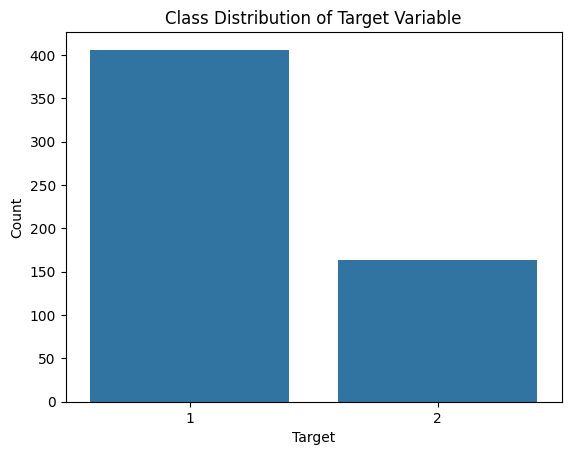

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Target', data=df)

plt.title("Class Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

The target variable distribution shows that the dataset is imbalanced, with significantly more samples belonging to class 1 than class 2. Class imbalance can negatively impact model performance because the model may become biased toward the majority class. We will be using CLASS WEIGHT because it give higher importance to minority class during training.


```
**Small dataset → Class weights
Medium dataset → SMOTE
Deep learning → Focal loss**

```



# ##univariate analysis

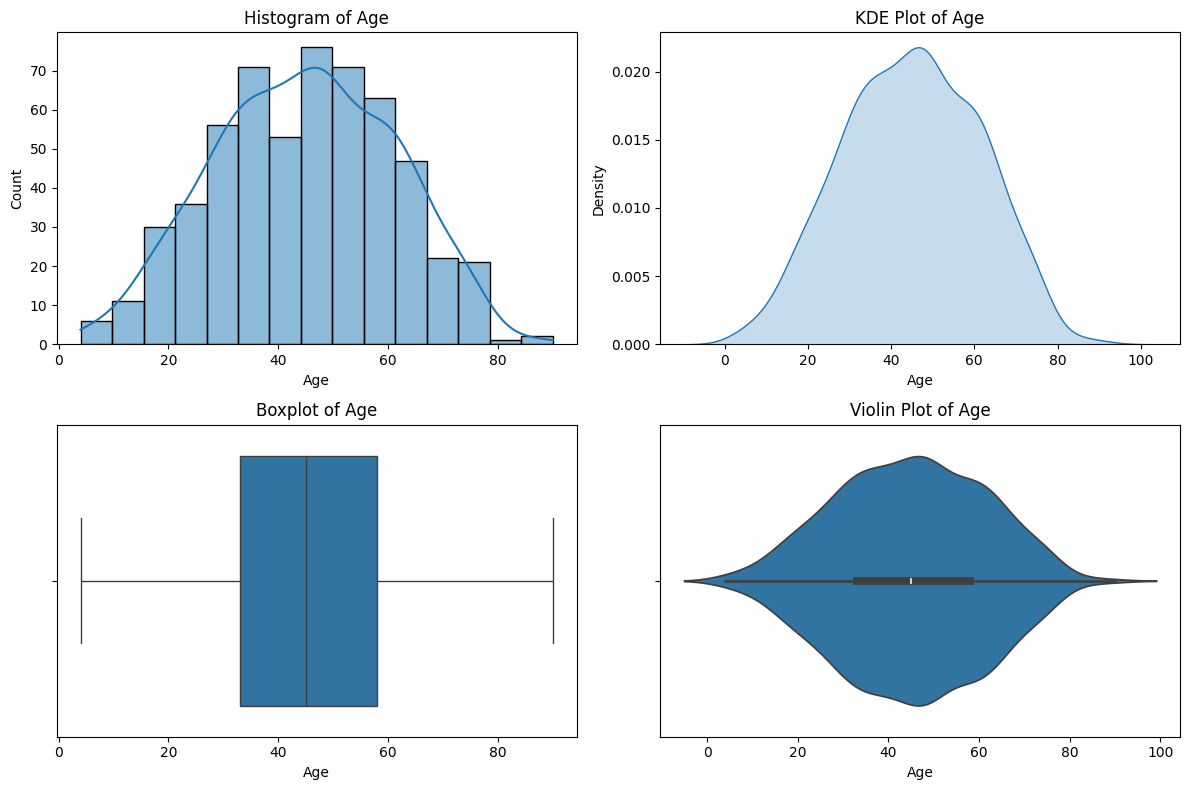

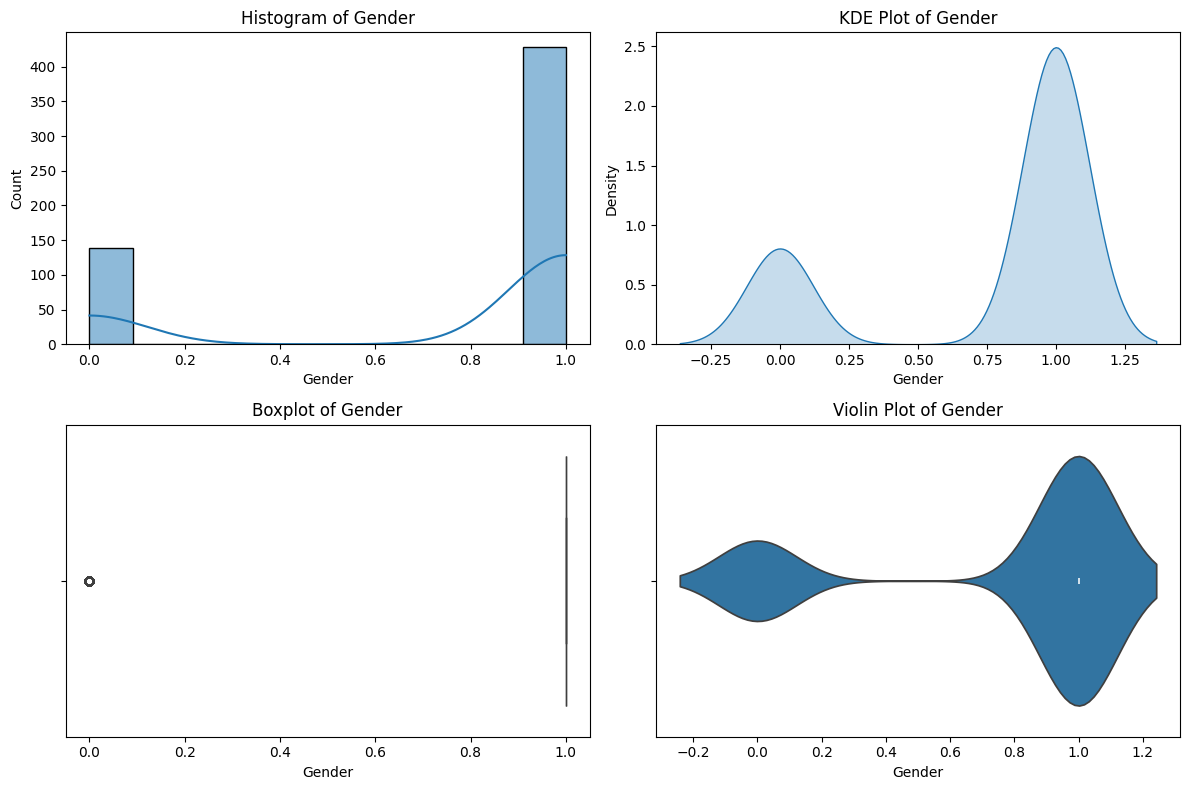

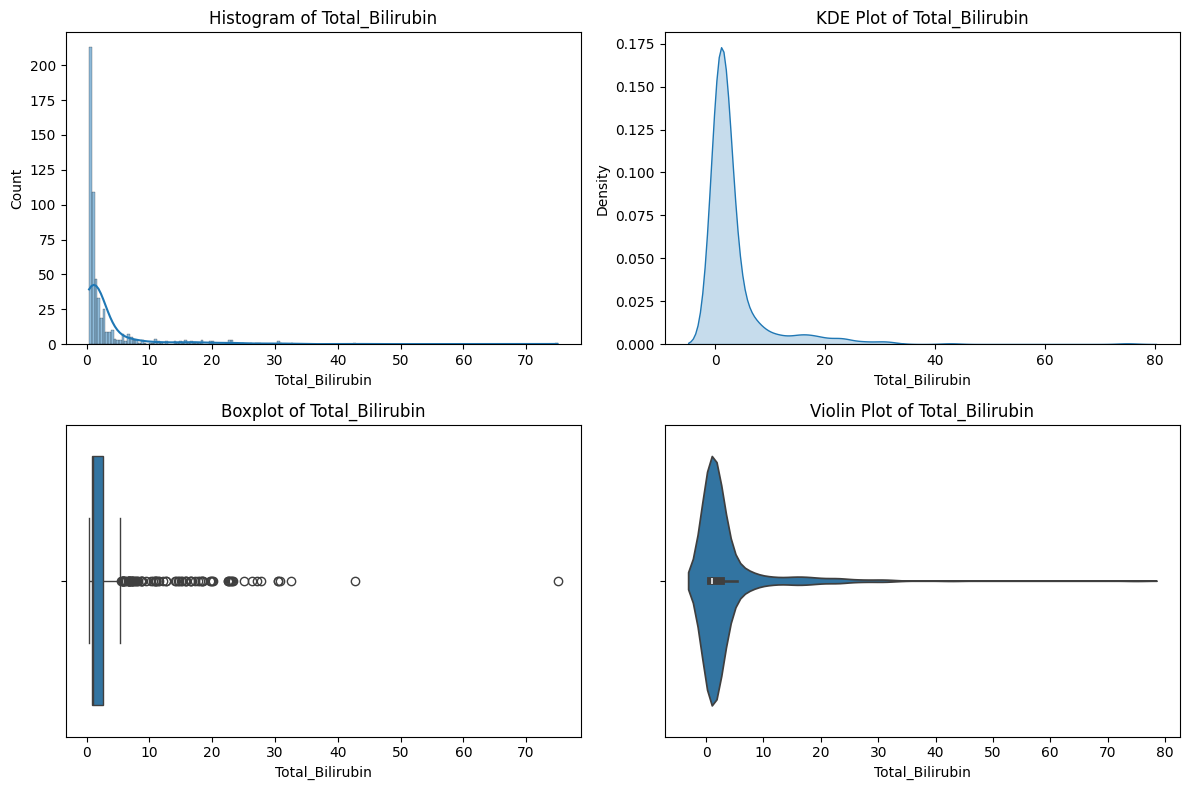

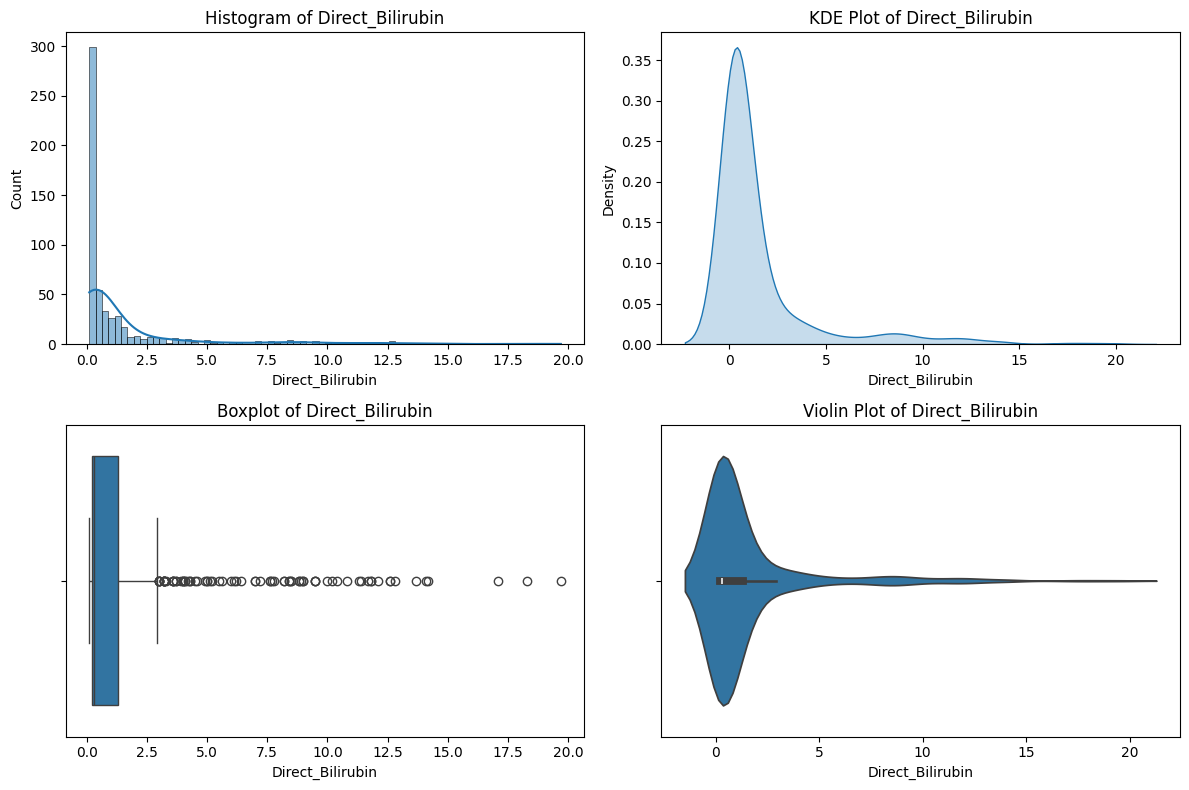

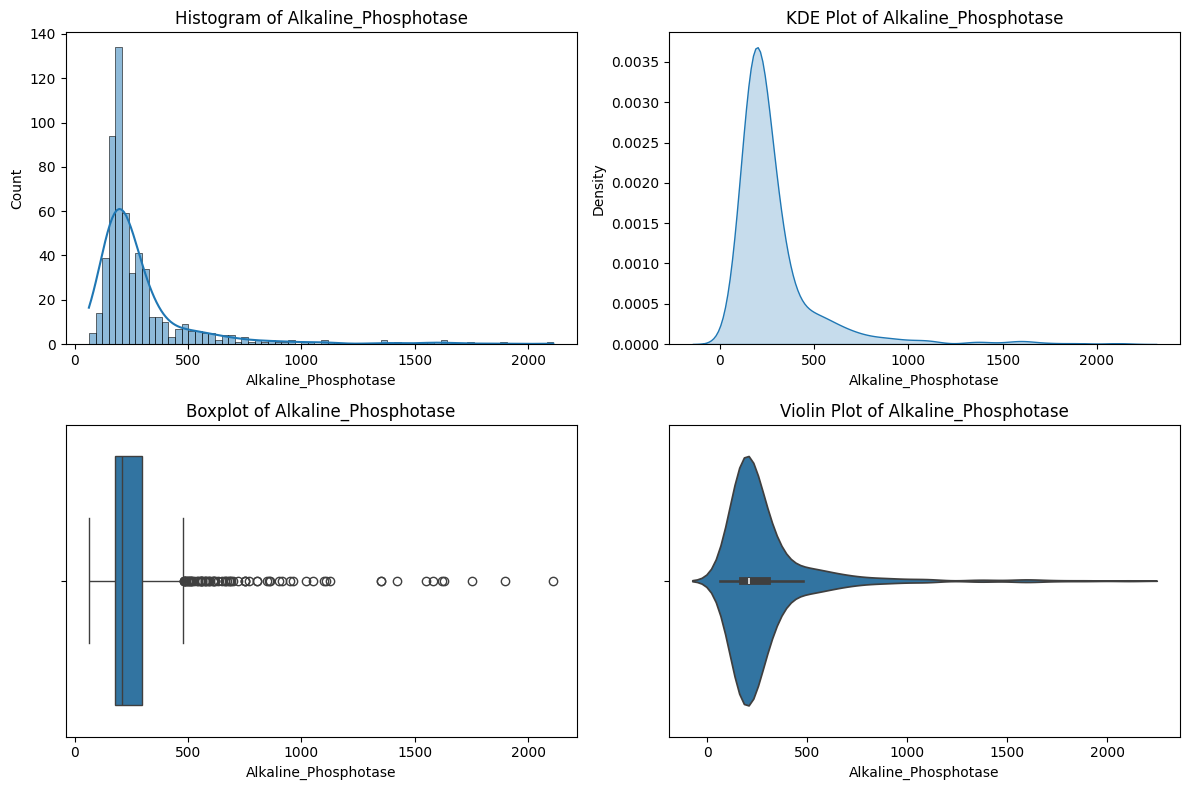

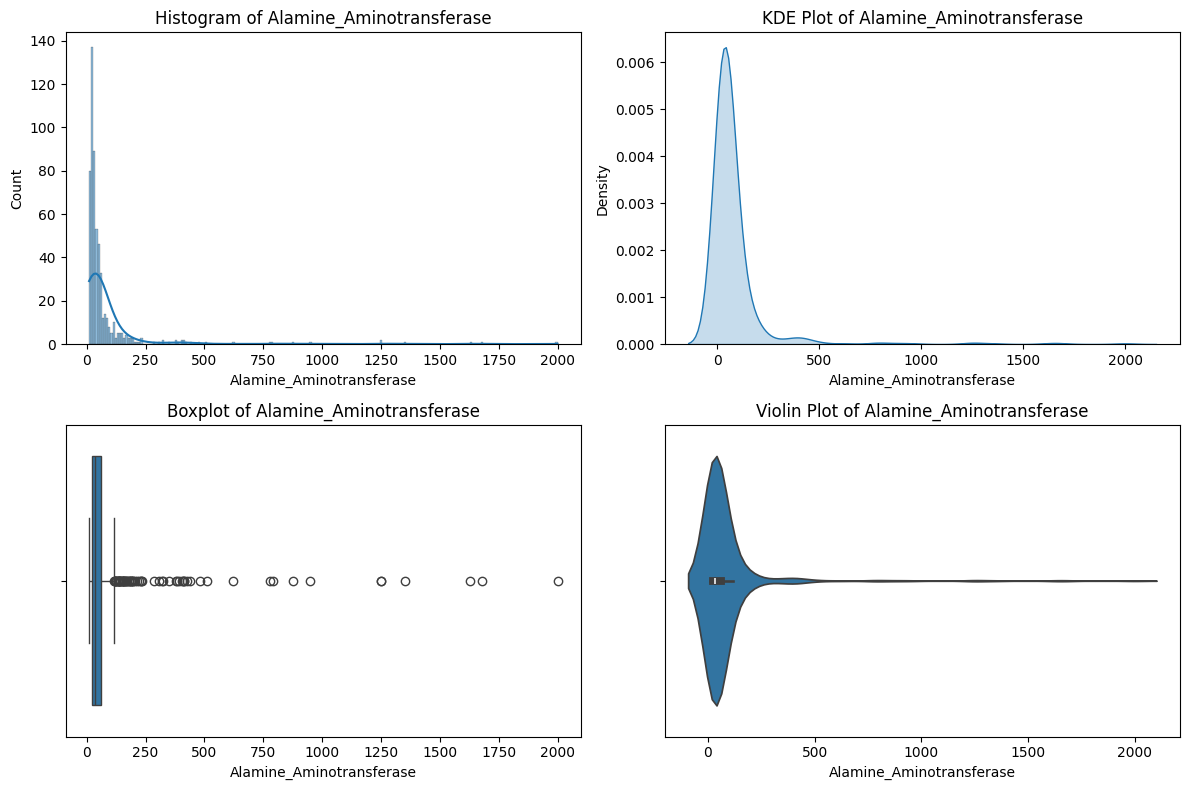

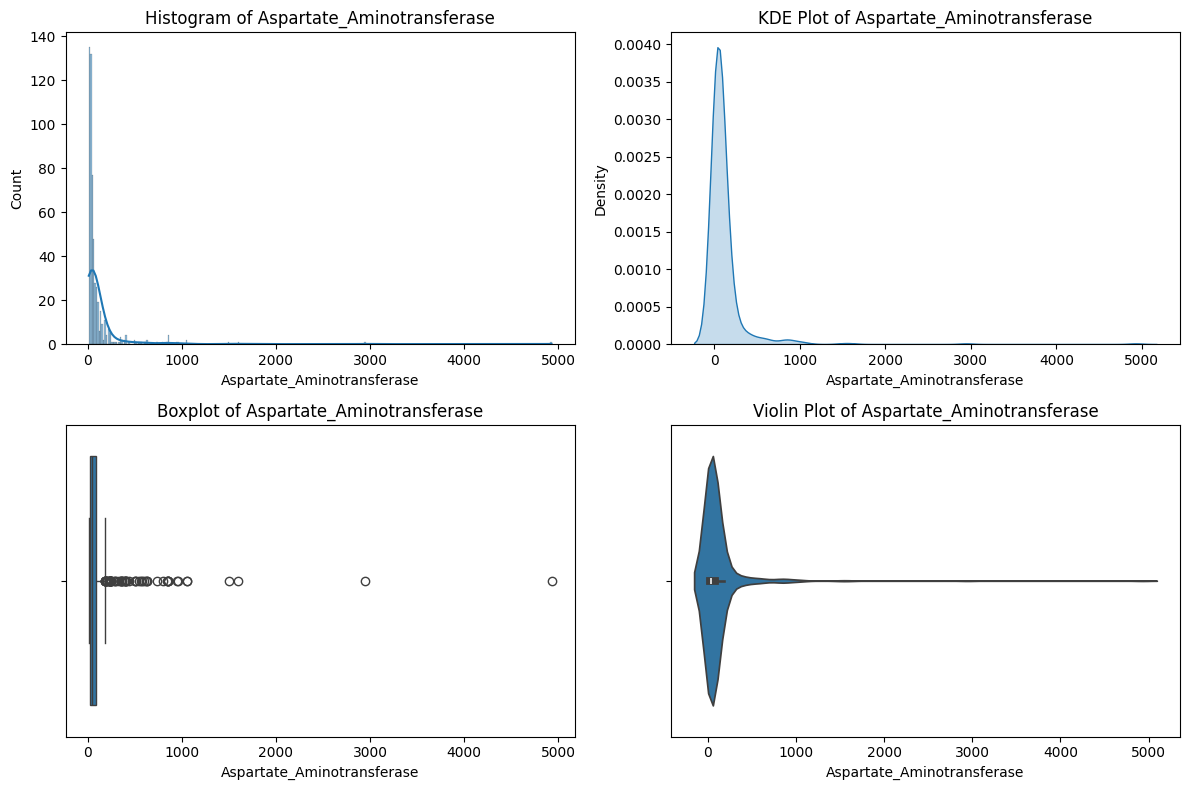

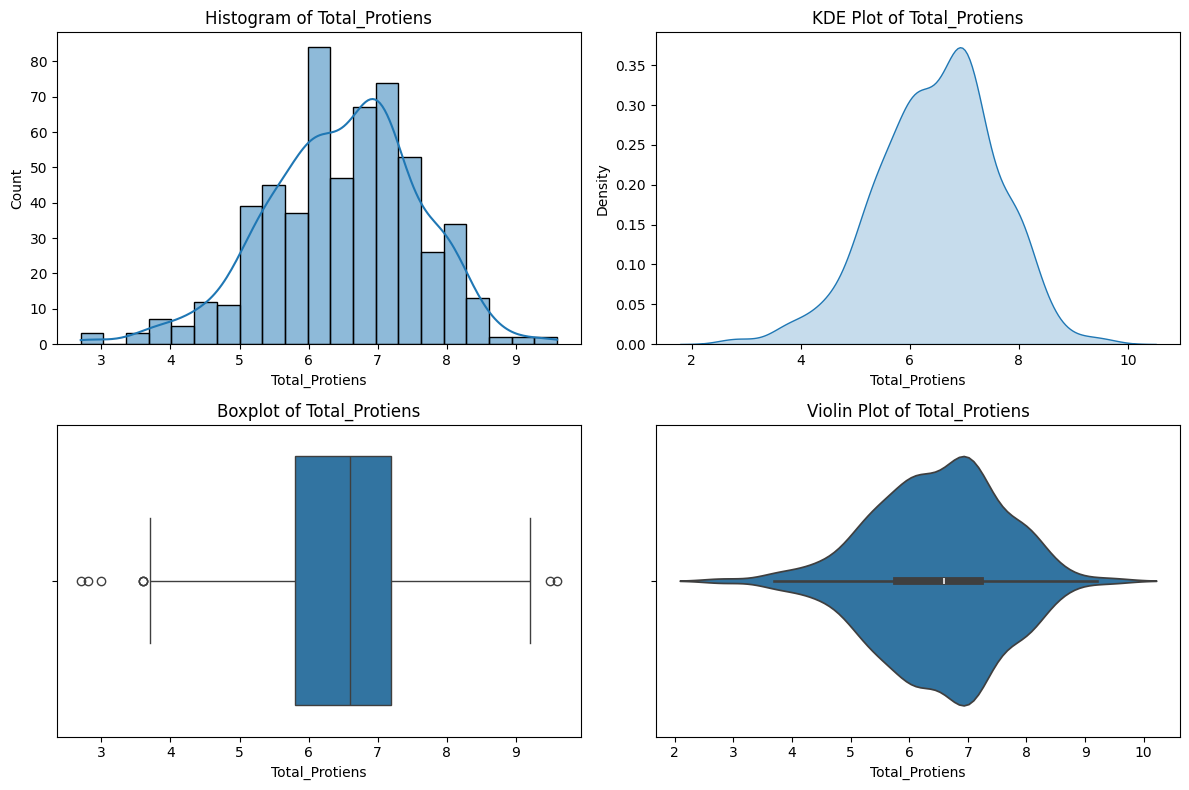

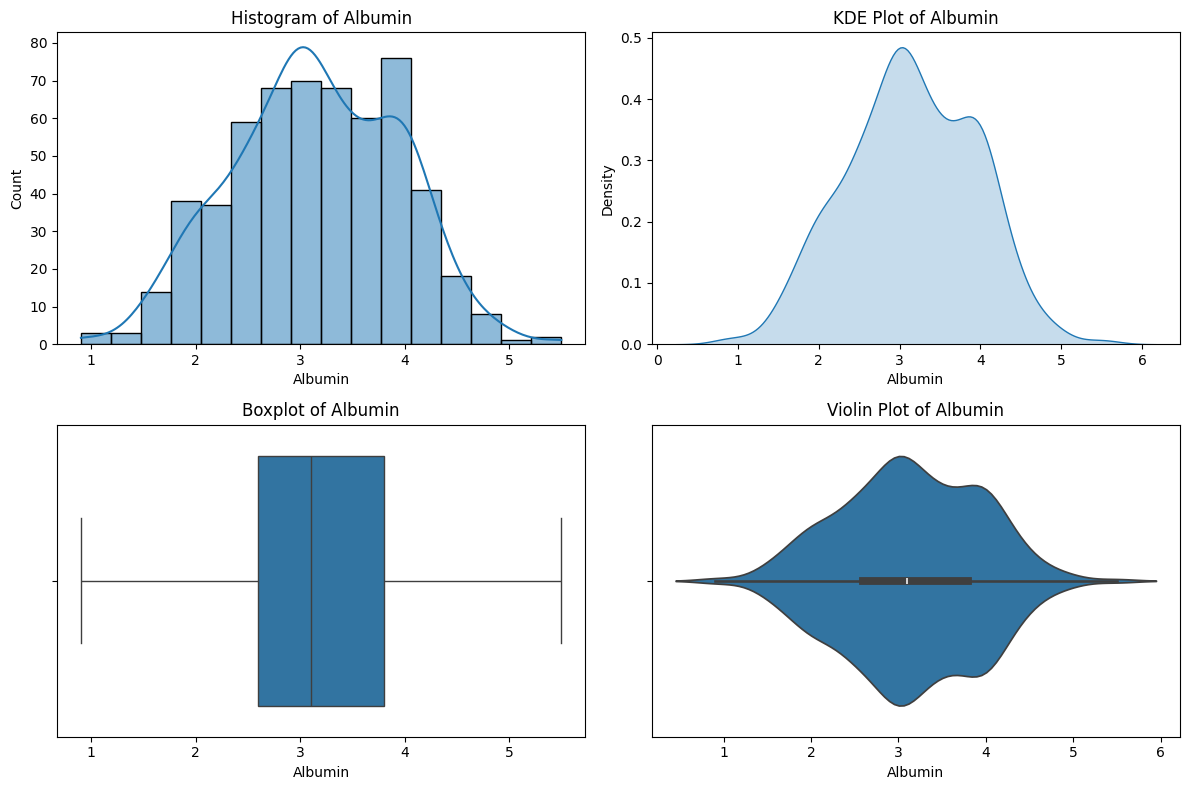

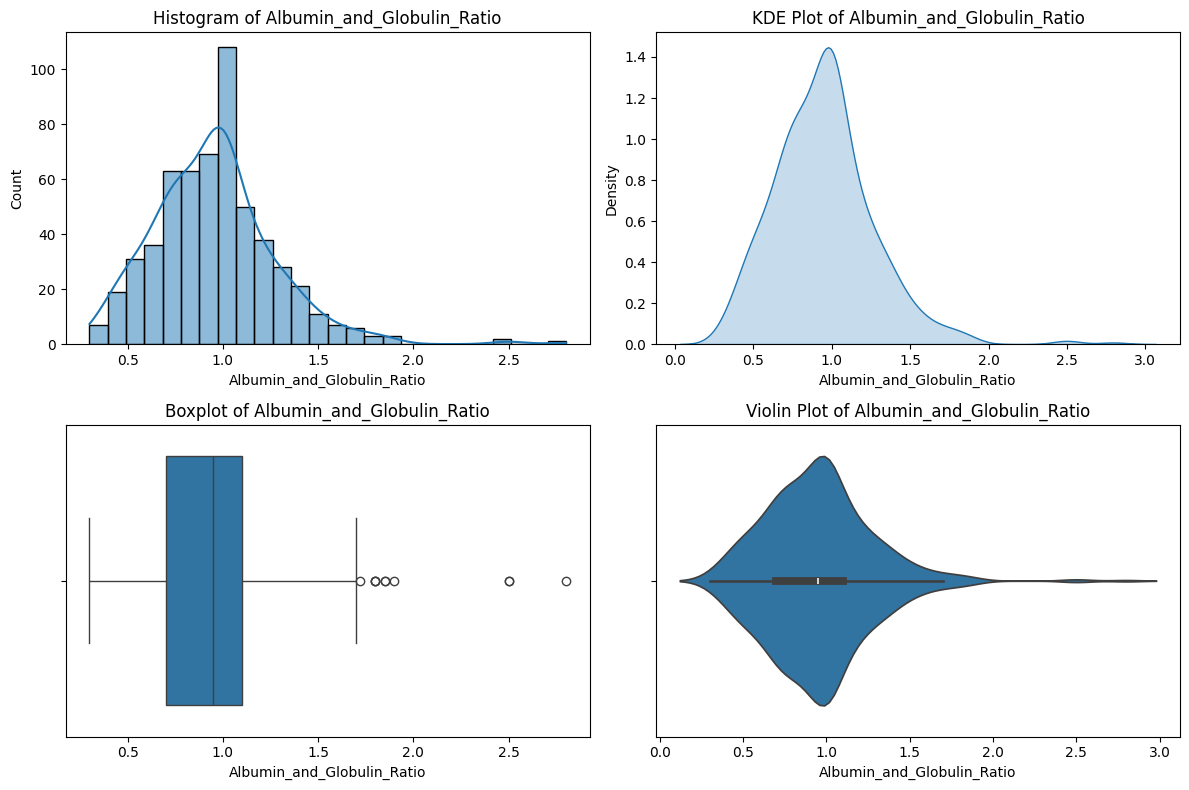

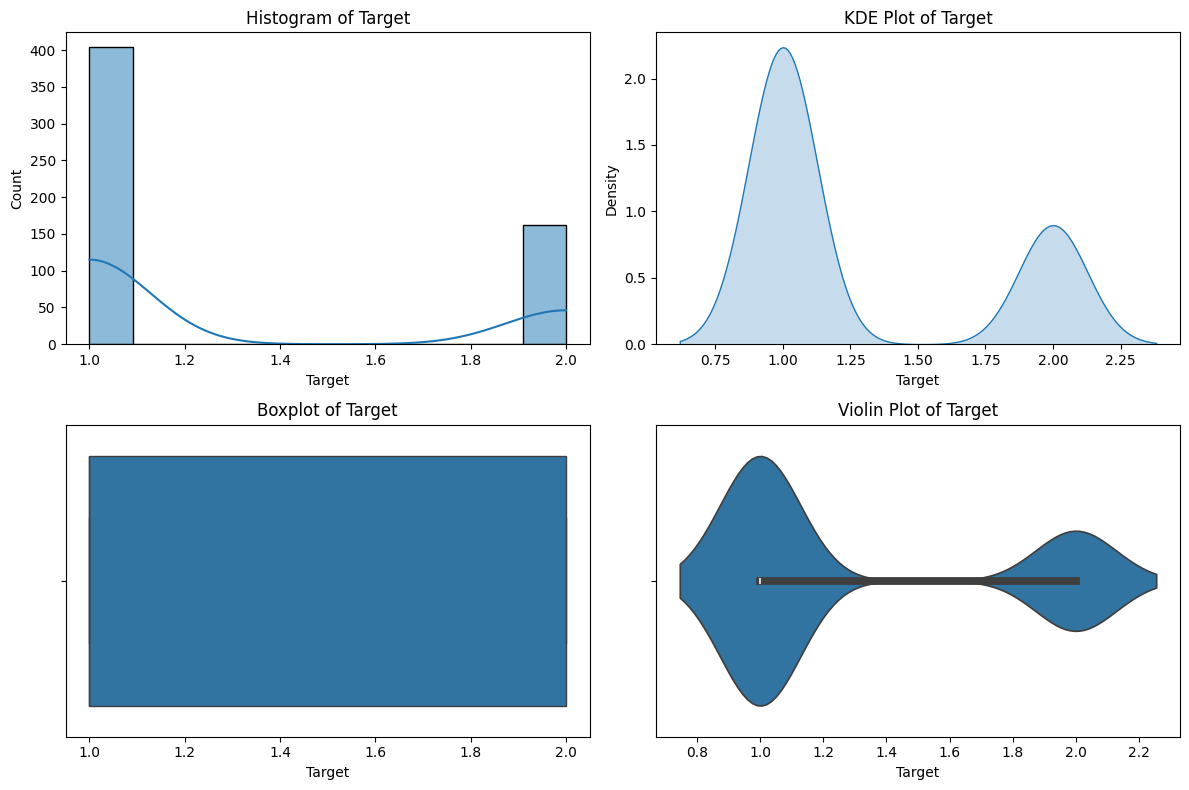

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    plt.figure(figsize=(12,8))

    # Histogram
    plt.subplot(2,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    # KDE Plot
    plt.subplot(2,2,2)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'KDE Plot of {col}')

    # Boxplot
    plt.subplot(2,2,3)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    # Violin Plot
    plt.subplot(2,2,4)
    sns.violinplot(x=df[col])
    plt.title(f'Violin Plot of {col}')

    plt.tight_layout()
    plt.show()

##Univariate exploratory data analysis was performed to understand the distribution of individual features. Histograms, KDE plots, boxplots, and violin plots were used to examine skewness, detect outliers, and identify extreme values in the dataset.

In [34]:
import pandas as pd

# Select numeric columns (excluding target)
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('Target')

summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std Dev': df[num_cols].std(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
})

print(summary)

                                  Mean  Median     Std Dev   Skewness  \
Age                          44.886926   45.00   16.274893  -0.050998   
Gender                        0.756184    1.00    0.429763  -1.196437   
Total_Bilirubin               3.338869    1.00    6.286728   4.852444   
Direct_Bilirubin              1.505830    0.30    2.841485   3.174186   
Alkaline_Phosphotase        292.567138  208.00  245.936559   3.716540   
Alamine_Aminotransferase     80.143110   35.00  182.044881   6.672512   
Aspartate_Aminotransferase  109.892226   41.00  291.841897  10.524552   
Total_Protiens                6.494876    6.60    1.087512  -0.317937   
Albumin                       3.145583    3.10    0.795745  -0.065818   
Albumin_and_Globulin_Ratio    0.948004    0.95    0.319635   1.001294   

                              Kurtosis  
Age                          -0.570584  
Gender                       -0.570567  
Total_Bilirubin              36.262008  
Direct_Bilirubin             11.



```
 Mean ≠ Median   skewed distribution
  High kurtosis   presence of outliers
  Long tails      extreme values
```



In [35]:
for col in num_cols:
    mean = df[col].mean()
    median = df[col].median()
    kurt = df[col].kurt()

    if mean != median:
        print(col, "may be skewed")

    if kurt > 3:
        print(col, "may contain outliers")

Age may be skewed
Gender may be skewed
Total_Bilirubin may be skewed
Total_Bilirubin may contain outliers
Direct_Bilirubin may be skewed
Direct_Bilirubin may contain outliers
Alkaline_Phosphotase may be skewed
Alkaline_Phosphotase may contain outliers
Alamine_Aminotransferase may be skewed
Alamine_Aminotransferase may contain outliers
Aspartate_Aminotransferase may be skewed
Aspartate_Aminotransferase may contain outliers
Total_Protiens may be skewed
Albumin may be skewed
Albumin_and_Globulin_Ratio may be skewed
Albumin_and_Globulin_Ratio may contain outliers


##Bivariate EDA (Feature vs Target)

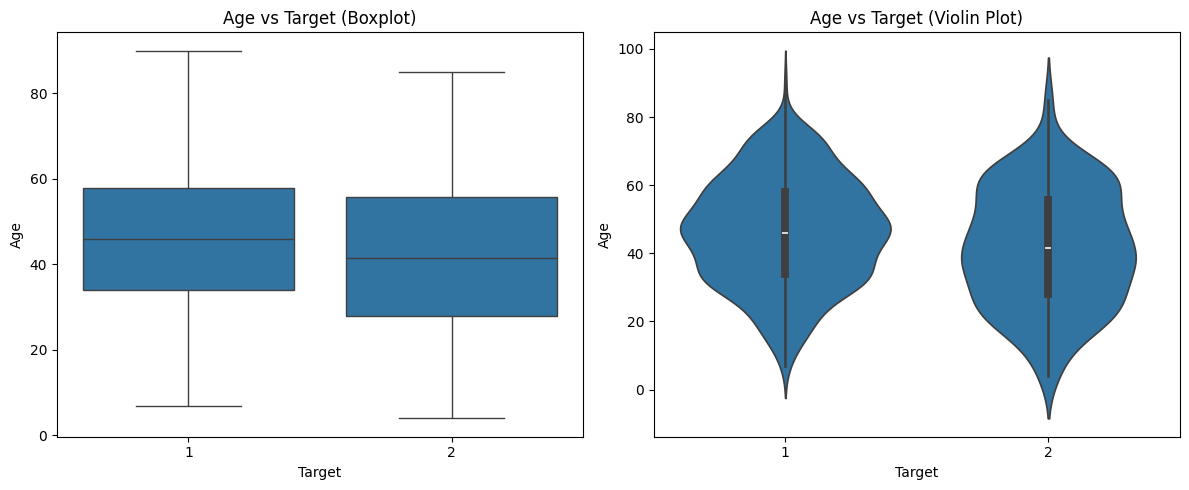

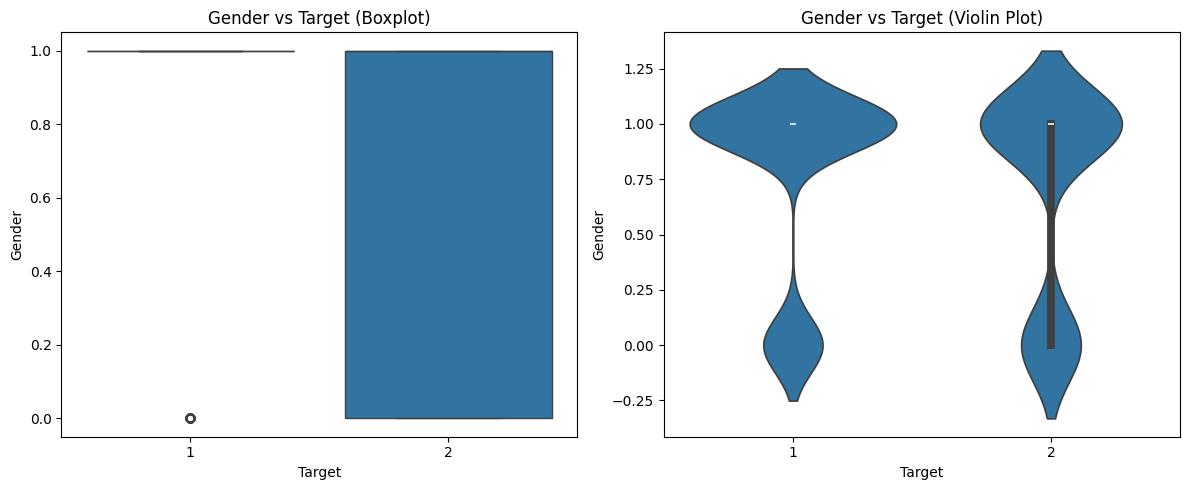

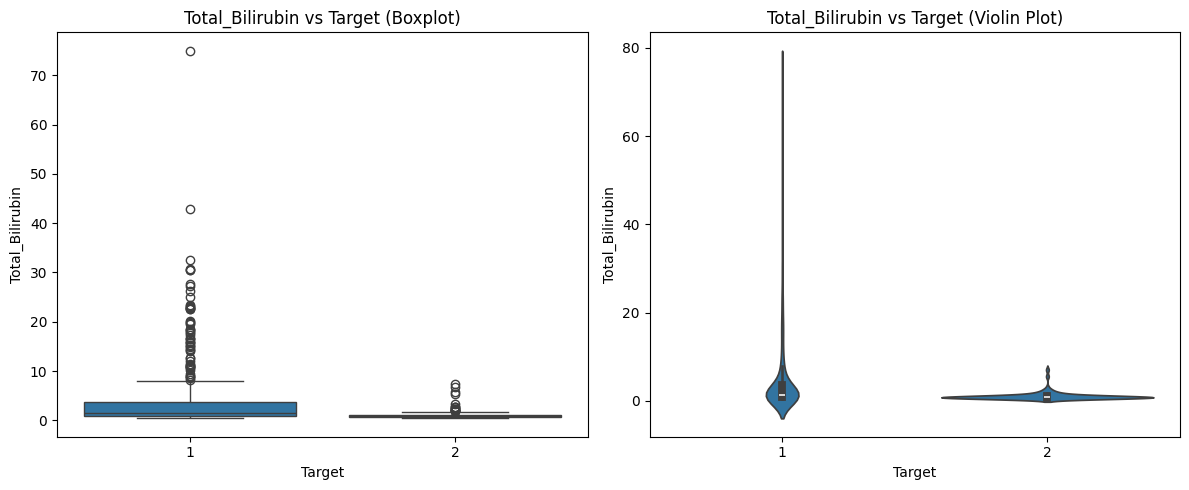

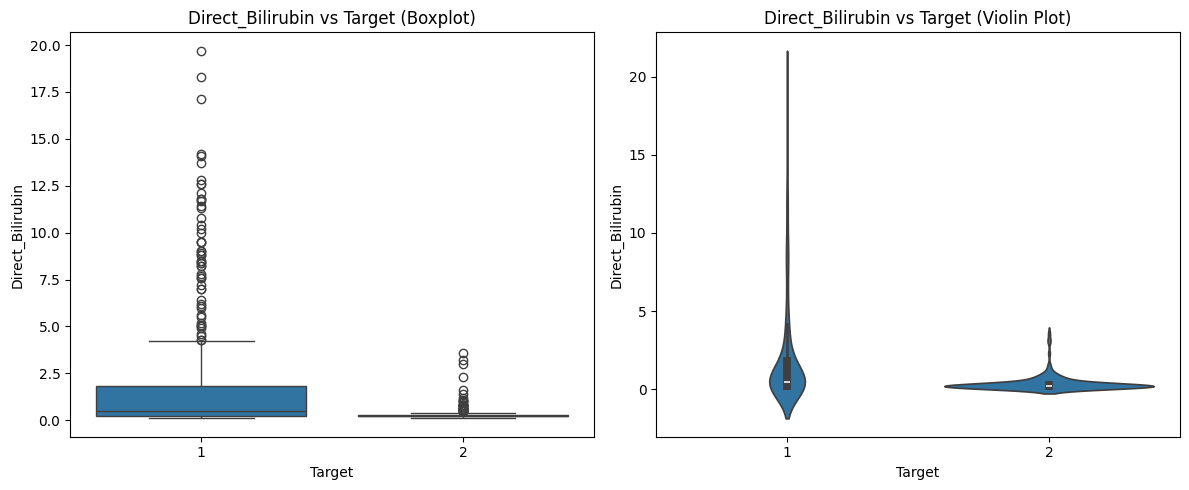

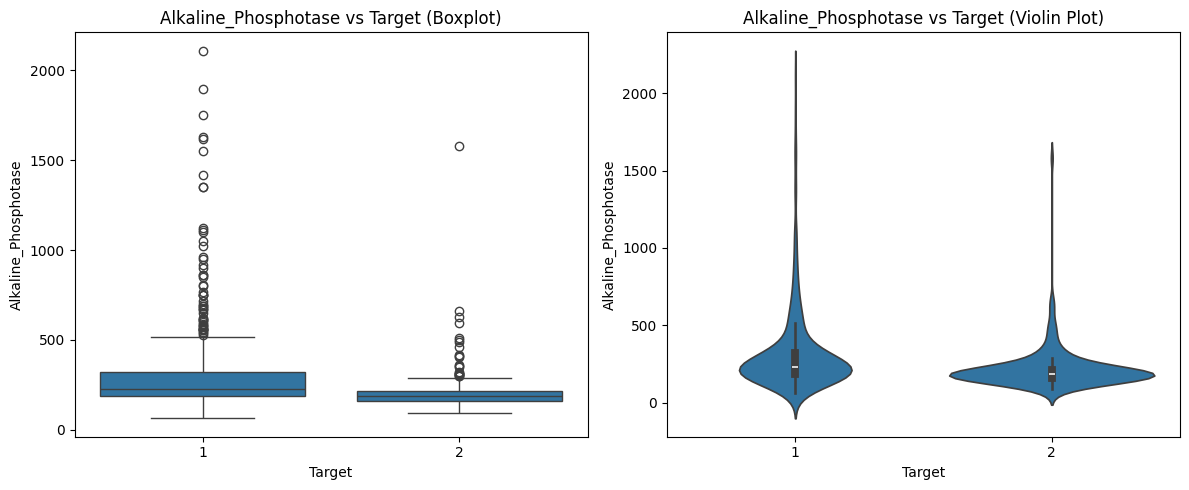

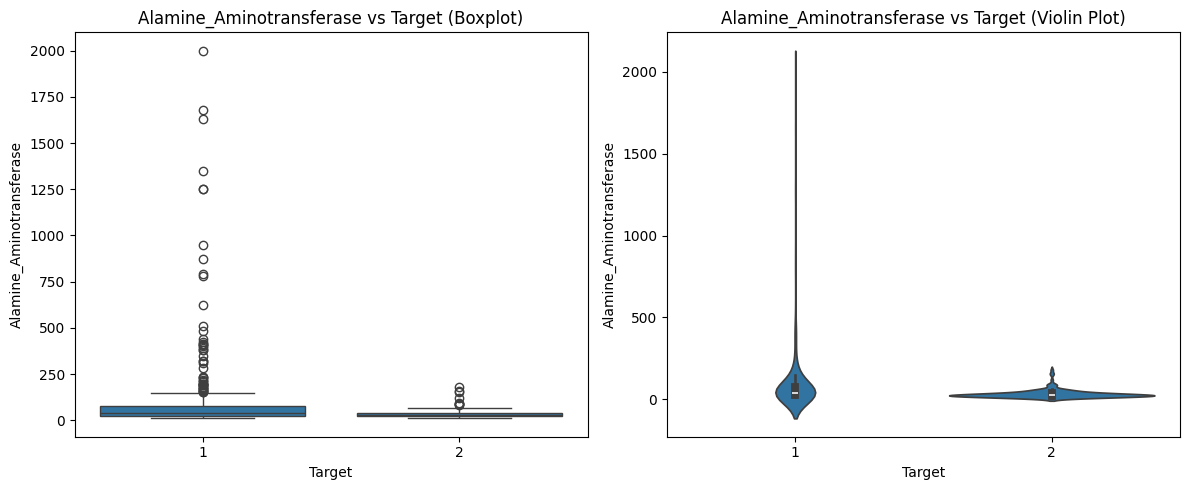

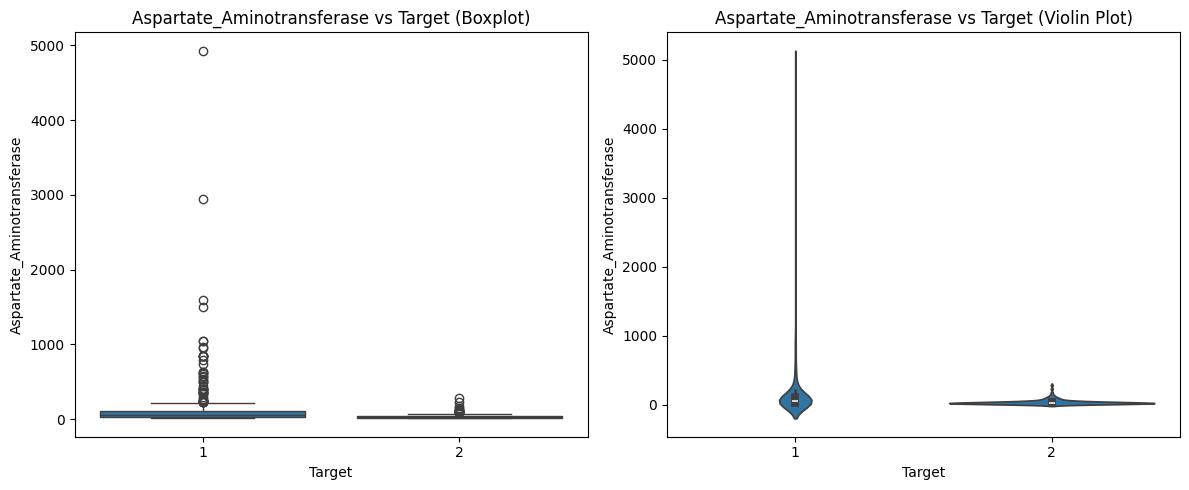

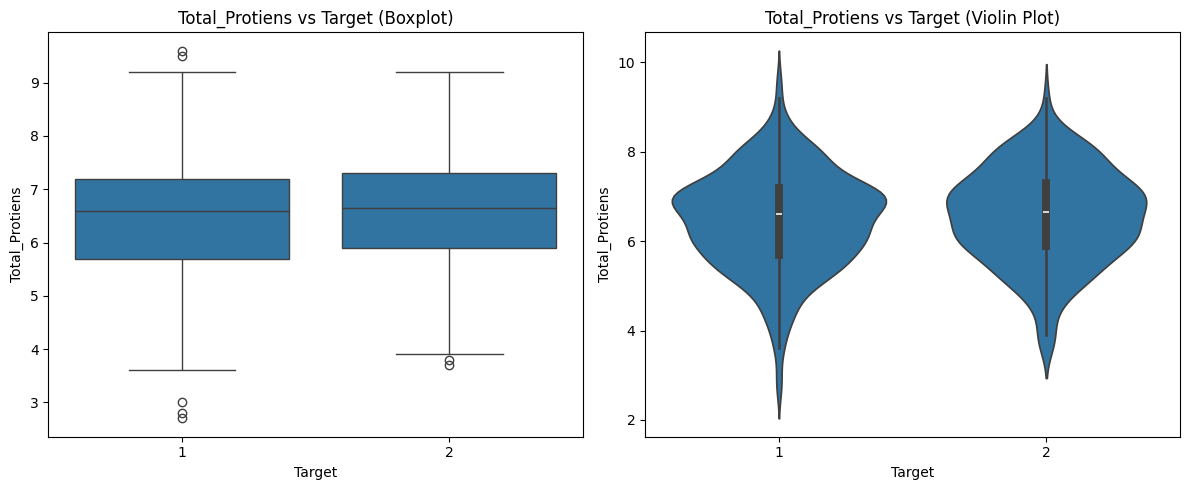

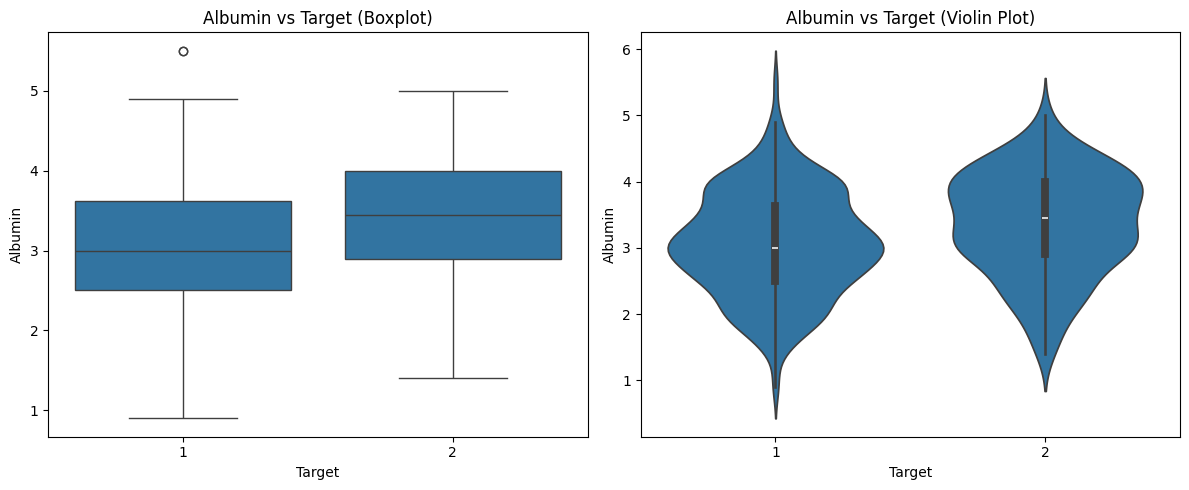

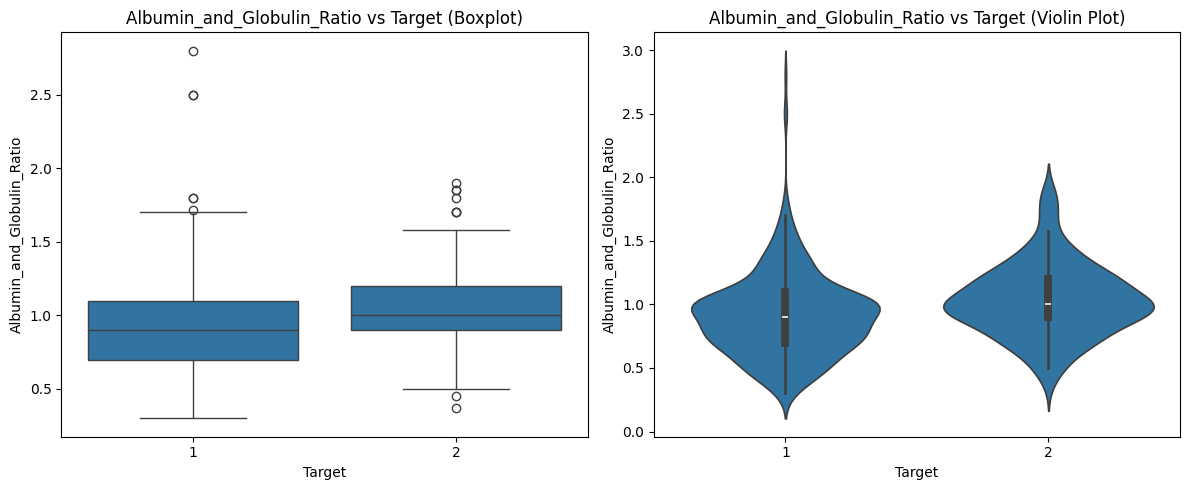

In [36]:
# select numeric columns except target
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('Target')

for col in num_cols:

    plt.figure(figsize=(12,5))

    # Boxplot
    plt.subplot(1,2,1)
    sns.boxplot(x='Target', y=col, data=df)
    plt.title(f'{col} vs Target (Boxplot)')

    # Violinplot
    plt.subplot(1,2,2)
    sns.violinplot(x='Target', y=col, data=df)
    plt.title(f'{col} vs Target (Violin Plot)')

    plt.tight_layout()
    plt.show()

Bivariate analysis was conducted using boxplots and violin plots to examine feature–target relationships. Liver disease patients tend to exhibit higher bilirubin and elevated enzyme levels (AST and ALT), indicating liver dysfunction.

## Correlation Analysis


```

    Pearson correlation
    Spearman correlation
```



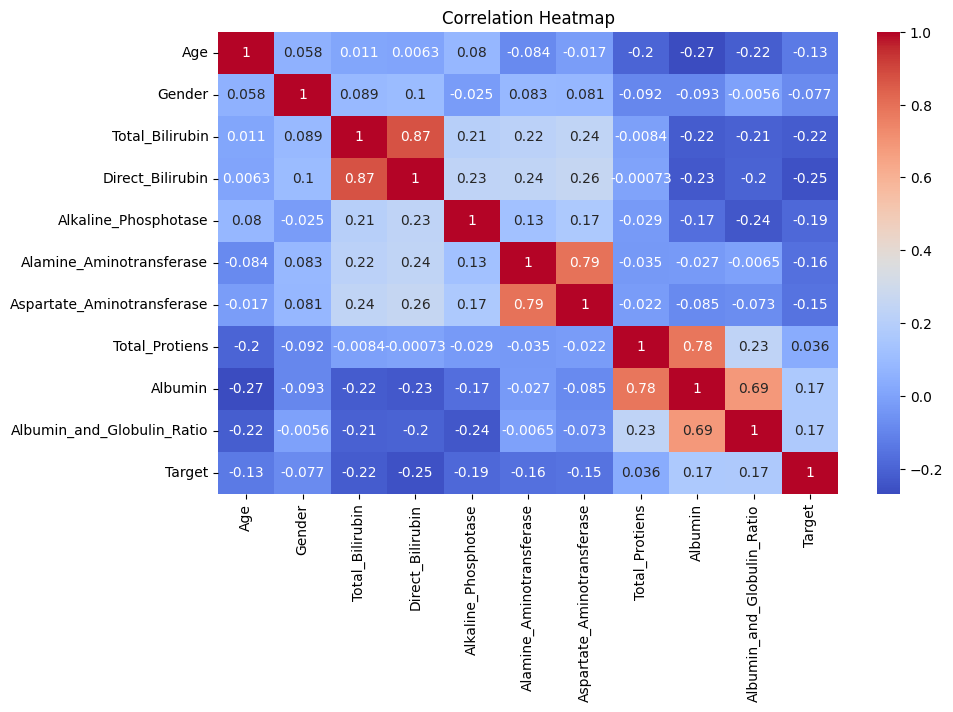

In [37]:
#pearson correlation
corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

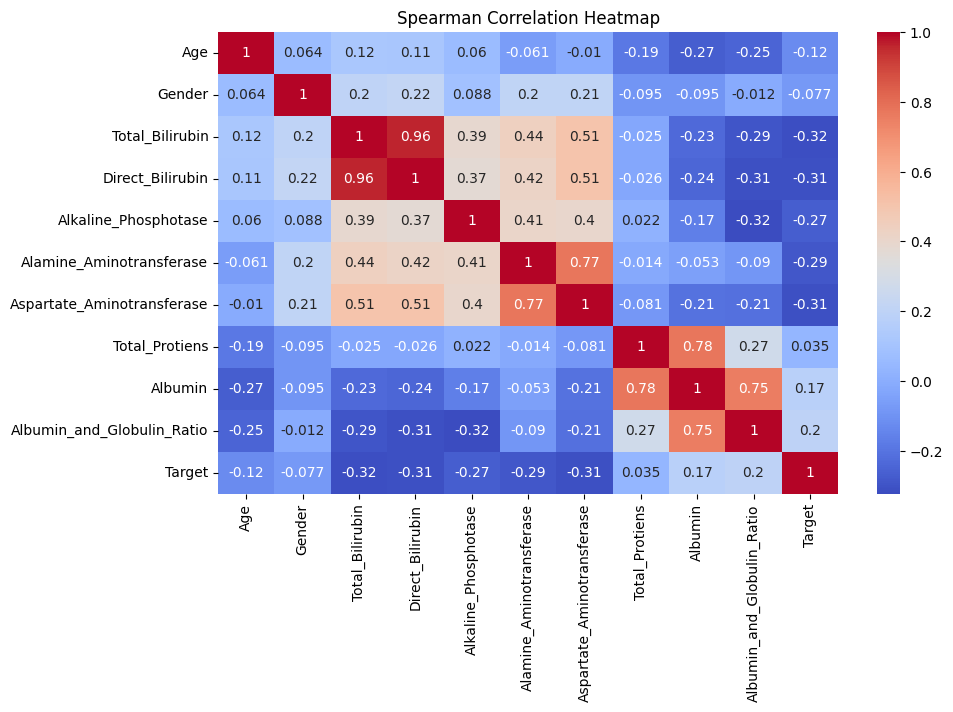

In [38]:
#spearman correlation
corr_spearman = df.corr(method='spearman')

plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm")

plt.title("Spearman Correlation Heatmap")
plt.show()

Correlation analysis was performed using Pearson and Spearman coefficients. Strong correlations were observed between Total Bilirubin and Direct Bilirubin, indicating potential multicollinearity between these variables.

## pairwise relationship (PAIRPLOT)

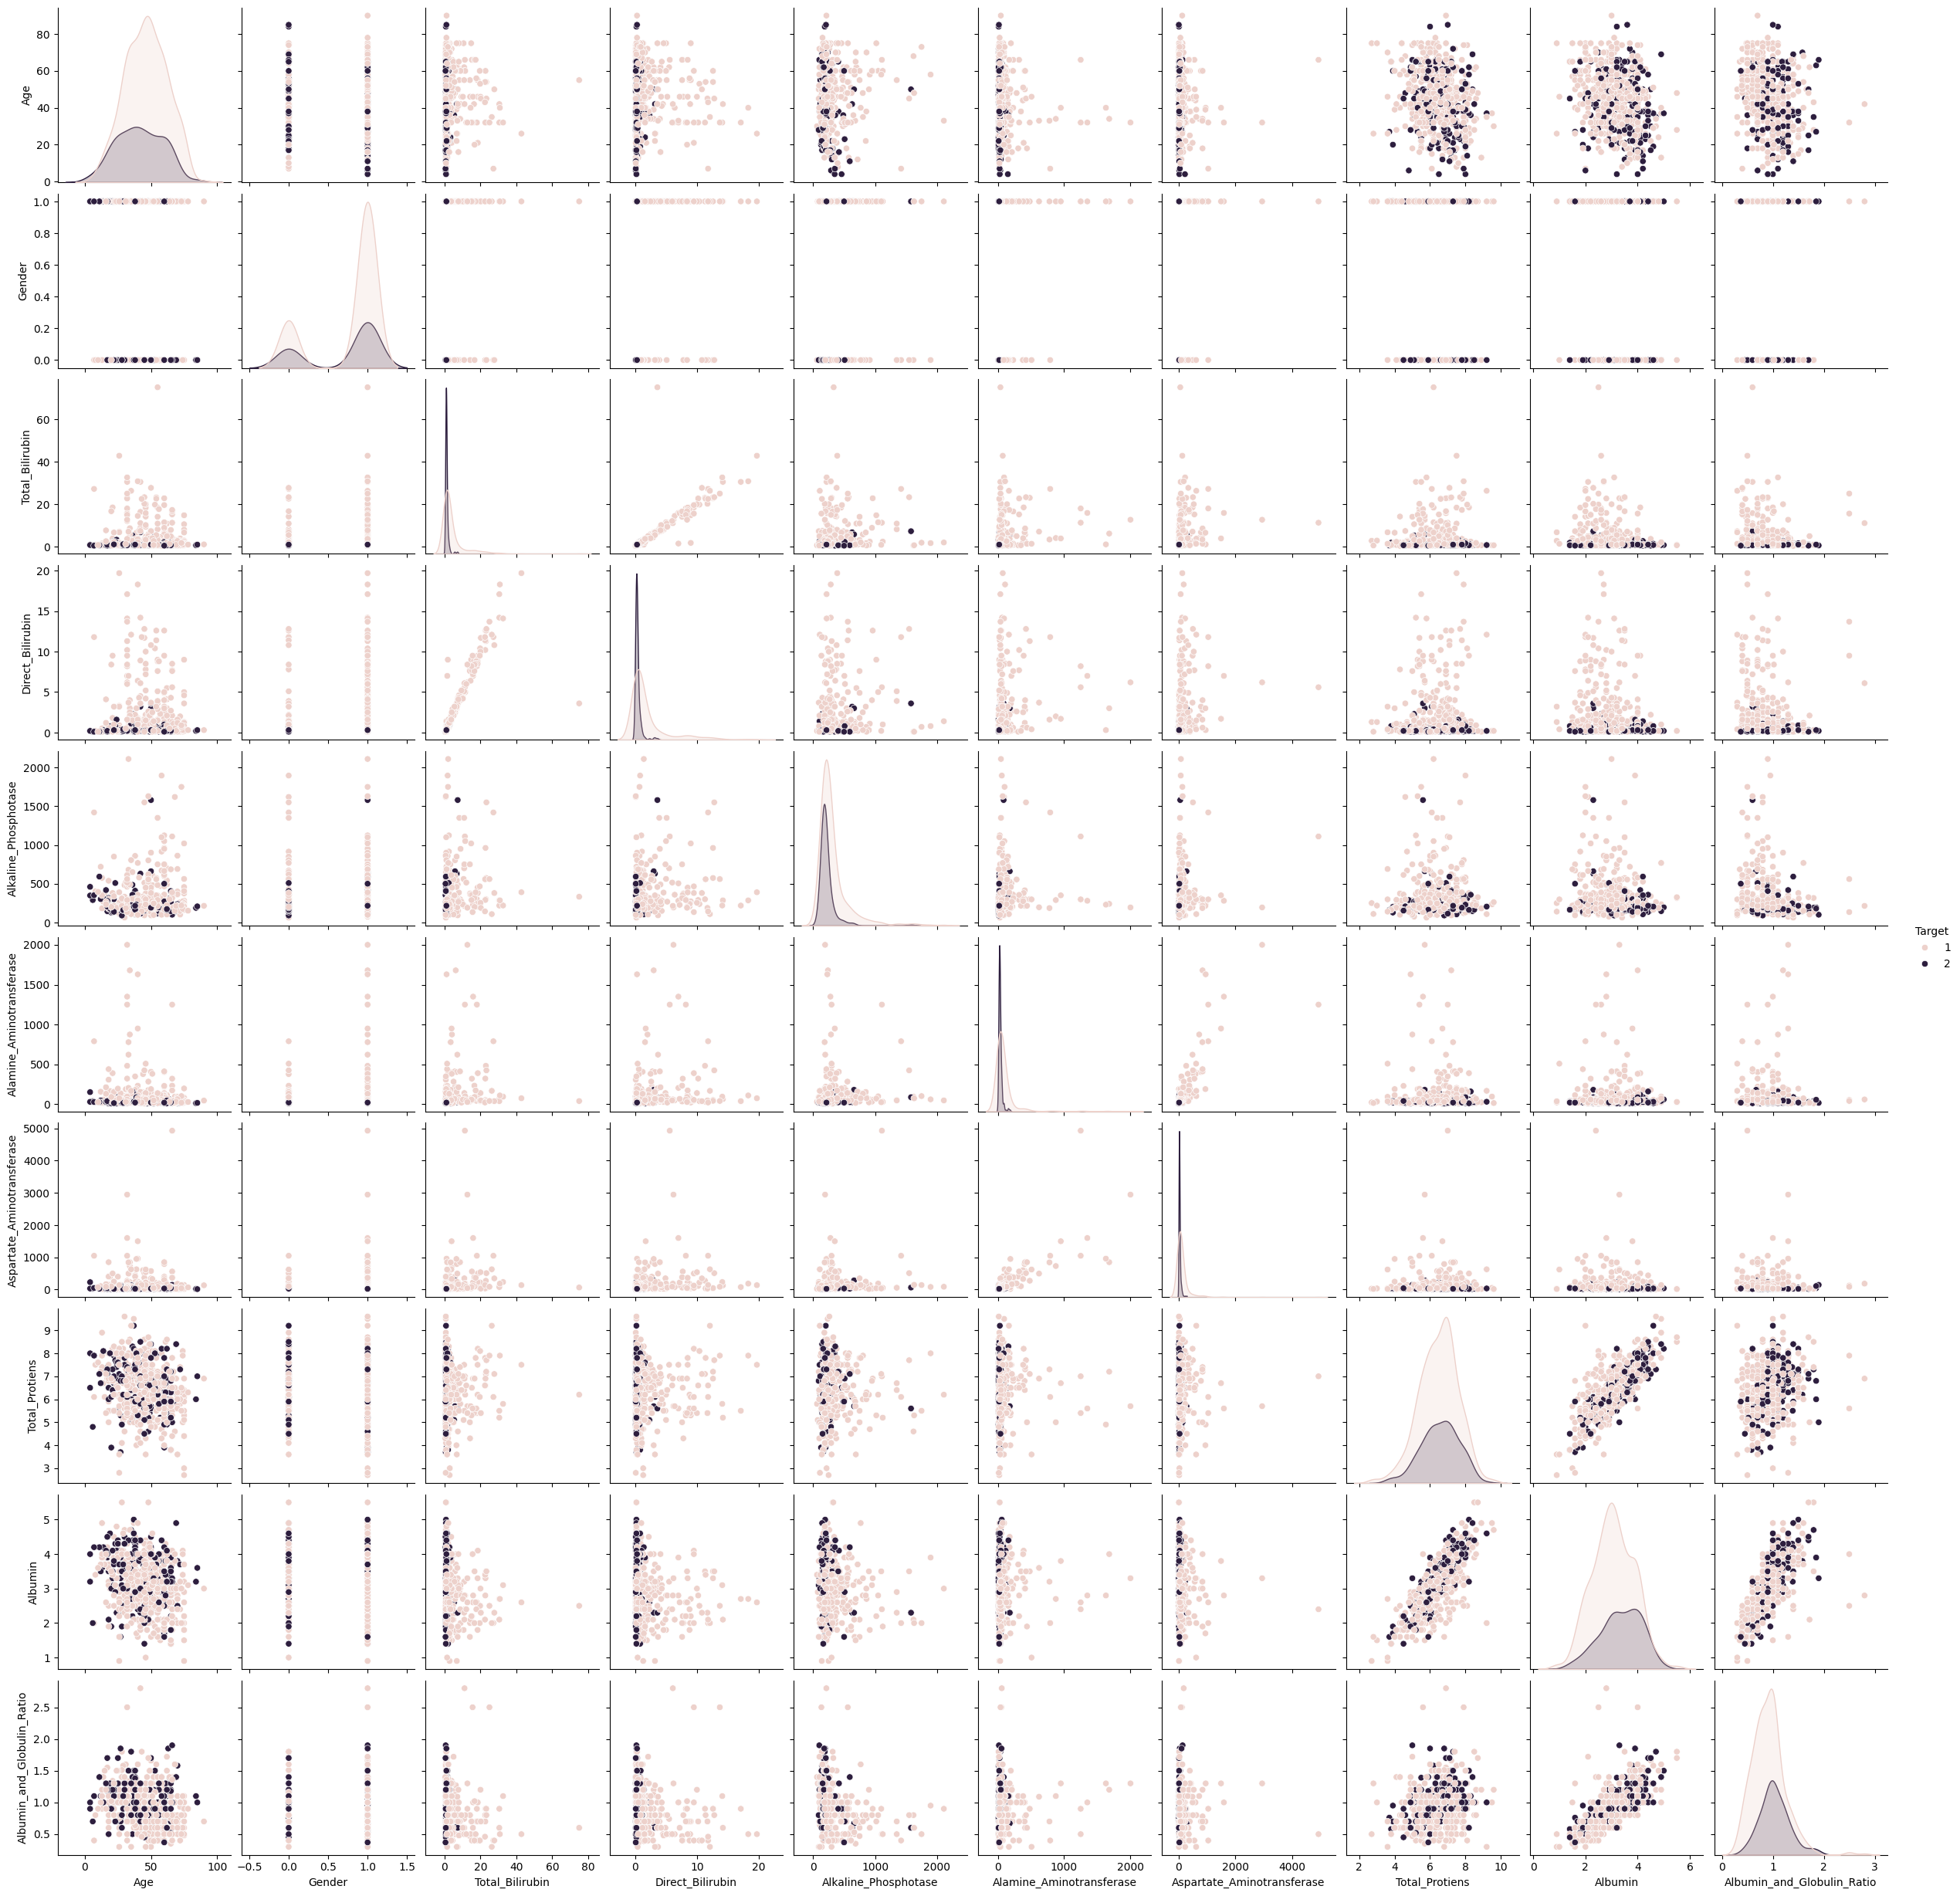

In [39]:
#PAIRPLOT
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='Target')

plt.show()

Pairwise relationships between selected features were visualized using a pairplot with the target variable as the hue. The plots reveal noticeable relationships among biochemical markers such as Total Bilirubin and Direct Bilirubin, indicating strong correlation between these variables.
Additionally, liver disease patients tend to exhibit higher levels of bilirubin and liver enzymes compared to non-disease patients. However, clear separation between classes is not always visible, suggesting that multiple features together may be required for accurate prediction.

##OUTLIER DETECTION USING


```
# BOXPLOT
# IQR = Interquartile Range
#Z-Score Method
# MODIFIED Z-Score Method
```



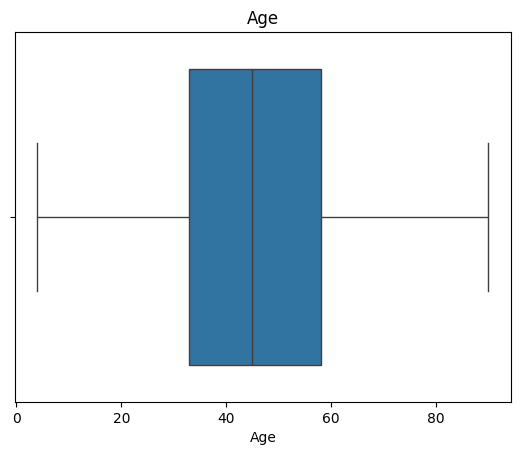

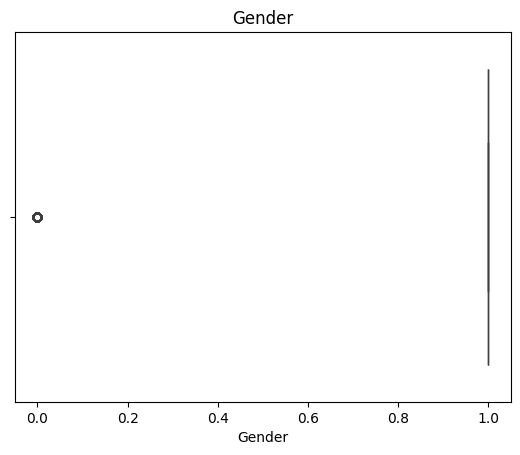

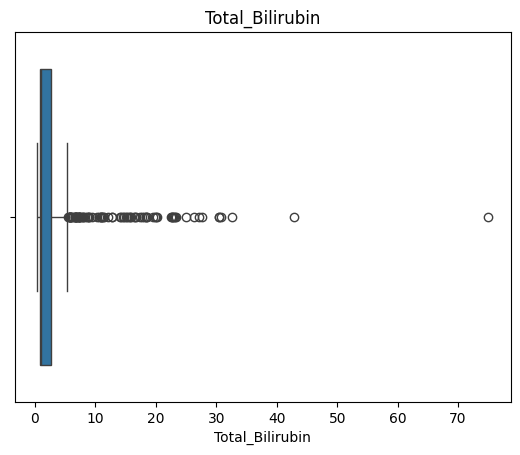

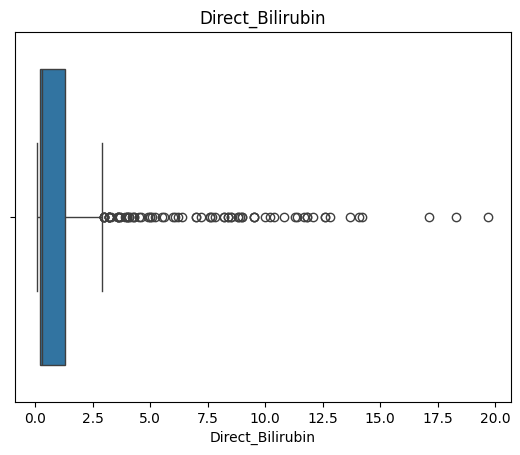

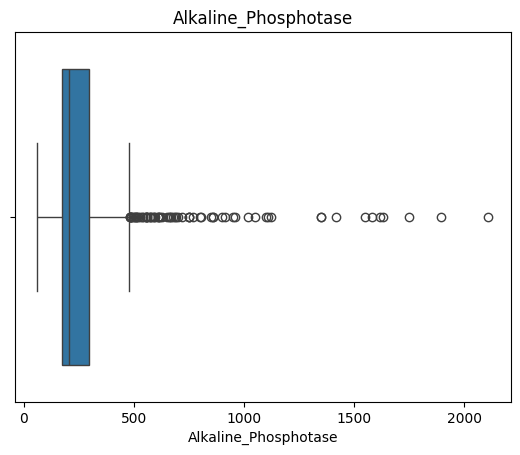

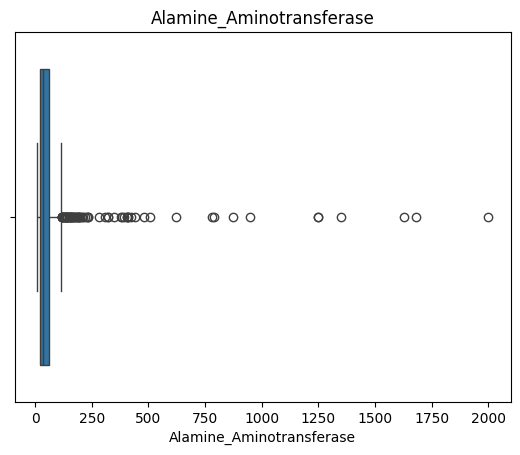

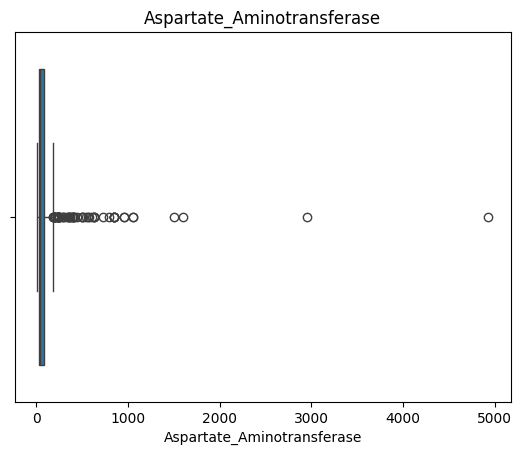

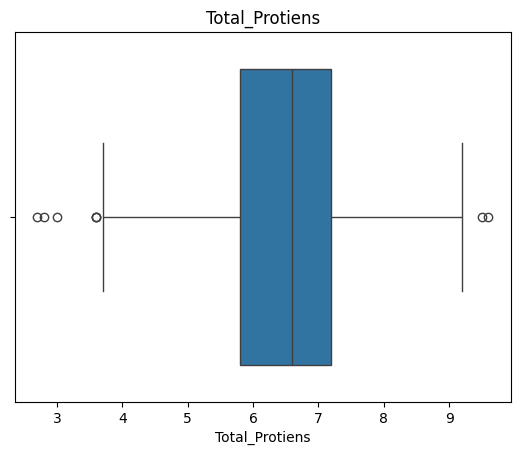

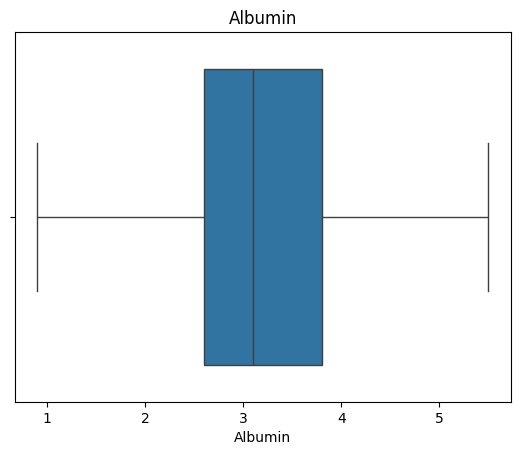

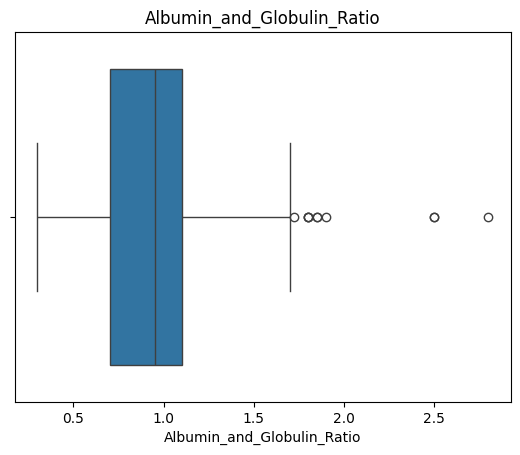

In [40]:
#boxplot
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col != 'Target':
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.show()

In [41]:
#IQR = Interquartile Range
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('Target')

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "outliers:", len(outliers))

Age outliers: 0
Gender outliers: 138
Total_Bilirubin outliers: 83
Direct_Bilirubin outliers: 80
Alkaline_Phosphotase outliers: 69
Alamine_Aminotransferase outliers: 71
Aspartate_Aminotransferase outliers: 64
Total_Protiens outliers: 8
Albumin outliers: 0
Albumin_and_Globulin_Ratio outliers: 10


In [42]:
#Z-Score Method
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(df[num_cols]))

outliers = (z_scores > 3).sum()

print(outliers)

71


Outlier detection was performed using multiple techniques including boxplots, interquartile range (IQR), and Z-score analysis. These methods helped identify extreme observations in biochemical markers such as bilirubin and liver enzymes, which may represent rare clinical cases or measurement anomalies.

In [43]:
# MODIFIED Z-Score Method
import numpy as np

num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('Target')

for col in num_cols:

    median = np.median(df[col])
    mad = np.median(np.abs(df[col] - median))

    modified_z = 0.6745 * (df[col] - median) / mad

    outliers = df[np.abs(modified_z) > 3.5]

    print(col, "outliers:", len(outliers))

Age outliers: 0
Gender outliers: 138
Total_Bilirubin outliers: 145
Direct_Bilirubin outliers: 133
Alkaline_Phosphotase outliers: 72
Alamine_Aminotransferase outliers: 74
Aspartate_Aminotransferase outliers: 80
Total_Protiens outliers: 2
Albumin outliers: 0
Albumin_and_Globulin_Ratio outliers: 9


In [44]:
df.to_csv('clean_data.csv', index=False)